In [1]:
import sys
from pathlib import Path

# Ensure project root is on sys.path so local modules (common, etc.) can be imported
_project_root = str(Path(__file__).resolve().parent.parent.parent) if "__file__" in dir() else str(Path.cwd().parent.parent)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)


import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS

model = "EGFR_MAPK__logobs"
data = "dream_cytof"
filename = "evaluate_all_figure1c"

df = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0)
df["N_features"] = df["features"].str.extract(r"RFE_(\d+)_permute")

In [2]:
val_df = df[df.dataset == "val"]
dmm_val_df = val_df[val_df.ref == "DMM"]
dmm_val_df = dmm_val_df[dmm_val_df.features.str.contains("RFE")]
dmm_val_df.N_features = dmm_val_df.N_features.astype("int")

In [3]:
dmm_val_df

,dataset,ref,model,samples,context,features,n_hidden,depth,dropout_rate,nn_init_scale,...,l1reg_inflater_output,l2reg_inflater_output,recon_loss,symm_reg,inflater_output_reg_epoch,job,n_epoch,inflater_bound,rmse,N_features
4607,val,DMM,EGFR_MAPK__logobs,HCC1500,transcriptomics,HVGRFE_128_permute,4.0,3.0,0.1,0.1,...,0.1,0.0,0.01,0.0,200.0,7.0,500.0,3.0,0.808504,128
4606,val,DMM,EGFR_MAPK__logobs,HCC1500,transcriptomics,HVGRFE_128_permute,4.0,3.0,0.1,0.1,...,0.1,0.0,0.01,0.0,200.0,6.0,500.0,3.0,0.729967,128
4605,val,DMM,EGFR_MAPK__logobs,HCC1500,transcriptomics,HVGRFE_128_permute,4.0,3.0,0.1,0.1,...,0.1,0.0,0.01,0.0,200.0,5.0,500.0,3.0,0.620285,128
4604,val,DMM,EGFR_MAPK__logobs,HCC1500,transcriptomics,HVGRFE_128_permute,4.0,3.0,0.1,0.1,...,0.1,0.0,0.01,0.0,200.0,4.0,500.0,3.0,0.799879,128
4603,val,DMM,EGFR_MAPK__logobs,HCC1500,transcriptomics,HVGRFE_128_permute,4.0,3.0,0.1,0.1,...,0.1,0.0,0.01,0.0,200.0,3.0,500.0,3.0,0.887218,128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5746,val,DMM,EGFR_MAPK__logobs,MCF7,proteomics,HVGRFE_128_permute,4.0,0.0,0.1,0.1,...,0.1,0.0,0.01,0.0,200.0,6.0,500.0,3.0,0.729932,128
5745,val,DMM,EGFR_MAPK__logobs,MCF7,proteomics,HVGRFE_128_permute,4.0,0.0,0.1,0.1,...,0.1,0.0,0.01,0.0,200.0,5.0,500.0,3.0,0.990085,128
5744,val,DMM,EGFR_MAPK__logobs,MCF7,proteomics,HVGRFE_128_permute,4.0,0.0,0.1,0.1,...,0.1,0.0,0.01,0.0,200.0,4.0,500.0,3.0,0.865015,128
5742,val,DMM,EGFR_MAPK__logobs,MCF7,proteomics,HVGRFE_128_permute,4.0,0.0,0.1,0.1,...,0.1,0.0,0.01,0.0,200.0,2.0,500.0,3.0,0.871306,128


In [4]:
dmm_val_df[dmm_val_df.context == "multimodal"].features.unique()

array(['RFE_8_permute', 'RFE_6_permute', 'RFE_4_permute',
       'RFE_28_permute', 'RFE_24_permute', 'RFE_20_permute',
       'RFE_32_permute', 'RFE_16_permute', 'RFE_10_permute',
       'RFE_12_permute'], dtype=object)

In [5]:
dmm_val_df

,dataset,ref,model,samples,context,features,n_hidden,depth,dropout_rate,nn_init_scale,...,l1reg_inflater_output,l2reg_inflater_output,recon_loss,symm_reg,inflater_output_reg_epoch,job,n_epoch,inflater_bound,rmse,N_features
4607,val,DMM,EGFR_MAPK__logobs,HCC1500,transcriptomics,HVGRFE_128_permute,4.0,3.0,0.1,0.1,...,0.1,0.0,0.01,0.0,200.0,7.0,500.0,3.0,0.808504,128
4606,val,DMM,EGFR_MAPK__logobs,HCC1500,transcriptomics,HVGRFE_128_permute,4.0,3.0,0.1,0.1,...,0.1,0.0,0.01,0.0,200.0,6.0,500.0,3.0,0.729967,128
4605,val,DMM,EGFR_MAPK__logobs,HCC1500,transcriptomics,HVGRFE_128_permute,4.0,3.0,0.1,0.1,...,0.1,0.0,0.01,0.0,200.0,5.0,500.0,3.0,0.620285,128
4604,val,DMM,EGFR_MAPK__logobs,HCC1500,transcriptomics,HVGRFE_128_permute,4.0,3.0,0.1,0.1,...,0.1,0.0,0.01,0.0,200.0,4.0,500.0,3.0,0.799879,128
4603,val,DMM,EGFR_MAPK__logobs,HCC1500,transcriptomics,HVGRFE_128_permute,4.0,3.0,0.1,0.1,...,0.1,0.0,0.01,0.0,200.0,3.0,500.0,3.0,0.887218,128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5746,val,DMM,EGFR_MAPK__logobs,MCF7,proteomics,HVGRFE_128_permute,4.0,0.0,0.1,0.1,...,0.1,0.0,0.01,0.0,200.0,6.0,500.0,3.0,0.729932,128
5745,val,DMM,EGFR_MAPK__logobs,MCF7,proteomics,HVGRFE_128_permute,4.0,0.0,0.1,0.1,...,0.1,0.0,0.01,0.0,200.0,5.0,500.0,3.0,0.990085,128
5744,val,DMM,EGFR_MAPK__logobs,MCF7,proteomics,HVGRFE_128_permute,4.0,0.0,0.1,0.1,...,0.1,0.0,0.01,0.0,200.0,4.0,500.0,3.0,0.865015,128
5742,val,DMM,EGFR_MAPK__logobs,MCF7,proteomics,HVGRFE_128_permute,4.0,0.0,0.1,0.1,...,0.1,0.0,0.01,0.0,200.0,2.0,500.0,3.0,0.871306,128


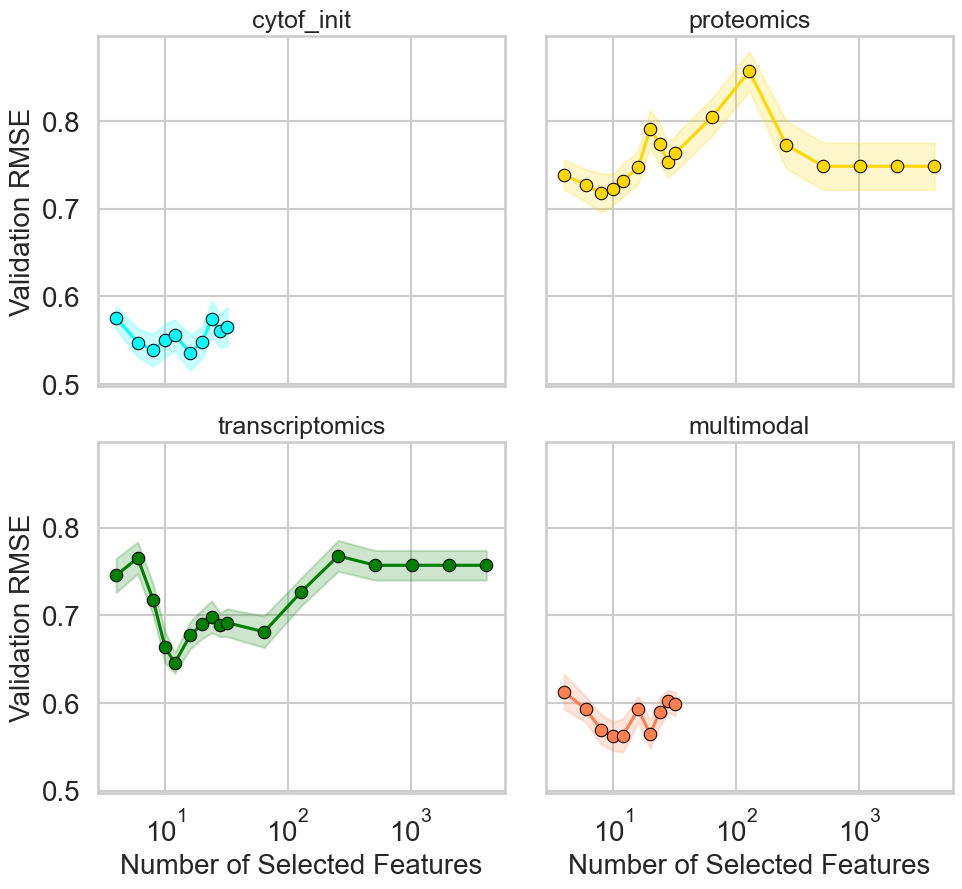

In [6]:
import matplotlib.pyplot as plt
# Set a modern style
sns.set_theme(style="whitegrid", context="talk")

palette = {
    "cytof_init": "cyan",
    "proteomics": "gold",
    "transcriptomics": "green",
    "multimodal": "coral",
}

g = sns.FacetGrid(
    dmm_val_df,
    col="context",
    col_order=palette.keys(),
    col_wrap=2,
    sharey=True,
    despine=False,
    height=5,
)

g.map_dataframe(
    sns.lineplot,
    x="N_features",
    y="rmse",
    marker='o',
    hue="context",
    palette=palette,
    mec="black",
    errorbar="se",
)

# Set x-axis to logarithmic scale
for ax in g.axes.flatten():
    ax.set_xscale("log")

# Add axis labels and titles
g.set_axis_labels("Number of Selected Features", "Validation RMSE", fontsize=20)
g.set_titles(col_template="{col_name}", fontsize=20)

# Enlarge tick labels
for ax in g.axes.flatten():
    ax.tick_params(axis='both', which='major', labelsize=20)


# Adjust layout
plt.subplots_adjust(top=0.85, wspace=0.10)
plt.show()

In [7]:
dmm_val_df[dmm_val_df.context == "cytof_init"].groupby("features").rmse.mean().sort_values()

features
RFE_16_permute    0.536041
RFE_8_permute     0.538709
RFE_6_permute     0.547351
RFE_20_permute    0.547921
RFE_10_permute    0.549866
RFE_12_permute    0.555896
RFE_28_permute    0.560852
RFE_32_permute    0.565385
RFE_24_permute    0.574674
RFE_4_permute     0.575756
Name: rmse, dtype: float64

In [8]:
dmm_val_df[dmm_val_df.context == "multimodal"].groupby("features").rmse.mean().sort_values()

features
RFE_10_permute    0.562219
RFE_12_permute    0.562879
RFE_20_permute    0.564748
RFE_8_permute     0.569657
RFE_24_permute    0.590008
RFE_16_permute    0.592728
RFE_6_permute     0.592766
RFE_32_permute    0.598559
RFE_28_permute    0.601976
RFE_4_permute     0.612621
Name: rmse, dtype: float64

In [9]:
dmm_val_df[dmm_val_df.context == "transcriptomics"].groupby("features").rmse.mean().sort_values()

features
HVGRFE_12_permute      0.645502
HVGRFE_10_permute      0.663866
HVGRFE_16_permute      0.677020
HVGRFE_64_permute      0.681100
HVGRFE_28_permute      0.689240
HVGRFE_20_permute      0.689828
HVGRFE_32_permute      0.691460
HVGRFE_24_permute      0.698100
HVGRFE_8_permute       0.717652
HVGRFE_128_permute     0.726667
HVGRFE_4_permute       0.745362
HVGRFE_512_permute     0.756953
HVGRFE_1024_permute    0.756953
HVGRFE_2048_permute    0.756953
HVGRFE_4096_permute    0.756953
HVGRFE_6_permute       0.765314
HVGRFE_256_permute     0.767666
Name: rmse, dtype: float64

In [10]:
dmm_val_df[dmm_val_df.context == "proteomics"].groupby("features").rmse.mean().sort_values()

features
HVGRFE_8_permute       0.718017
HVGRFE_10_permute      0.721967
HVGRFE_6_permute       0.726730
HVGRFE_12_permute      0.731821
HVGRFE_4_permute       0.738809
HVGRFE_16_permute      0.747202
HVGRFE_512_permute     0.748456
HVGRFE_4096_permute    0.748456
HVGRFE_1024_permute    0.748456
HVGRFE_2048_permute    0.748456
HVGRFE_28_permute      0.753742
HVGRFE_32_permute      0.763170
HVGRFE_256_permute     0.772755
HVGRFE_24_permute      0.773440
HVGRFE_20_permute      0.791179
HVGRFE_64_permute      0.804902
HVGRFE_128_permute     0.856610
Name: rmse, dtype: float64